In [1]:
!source ../.venv/bin/activate

In [2]:
import sys
print(sys.executable)

/home/jec061/cse151b_competition/.venv/bin/python


In [3]:
import sys
!{sys.executable} -m pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 26.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 27.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 23.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip


In [4]:
from pathlib import Path
import json

RESULTS_DIR = Path("results")  # relative to cwd; use Path("scripts/results") if cwd is repo root instead

def load_jsonl(path: Path):
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

results_modular = load_jsonl(RESULTS_DIR / "modular_results.jsonl")
results_baseline = load_jsonl(RESULTS_DIR / "original_results.jsonl")  # adjust filename if yours differs

print(len(results_modular), len(results_baseline))
print(results_modular[0].keys())

25 25
dict_keys(['id', 'is_mcq', 'gold', 'response', 'correct'])


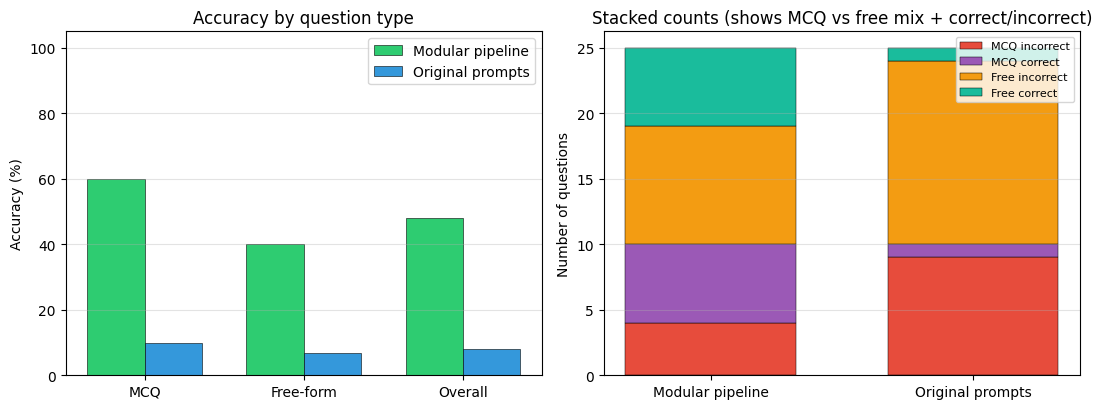

N modular: 25 (MCQ=10, free=15) | N baseline: 25 (MCQ=10, free=15)


In [6]:
"""
Compare modular vs original/baseline scored results.
"""
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def _load_jsonl(path: Path):
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


# Override paths if your files live elsewhere.
_RESULTS_DIR = Path("results")
_PATH_MODULAR = _RESULTS_DIR / "modular_results.jsonl"
_PATH_BASELINE = _RESULTS_DIR / "original_results.jsonl"

# Use in-memory lists if you already assigned them; otherwise load JSONL.
if globals().get("results_modular") is None:
    results_modular = _load_jsonl(_PATH_MODULAR)
if globals().get("results_baseline") is None:
    results_baseline = _load_jsonl(_PATH_BASELINE)

LABEL_MODULAR = "Modular pipeline"
LABEL_BASELINE = "Original prompts"


def _acc_subset(xs):
    return (sum(1 for x in xs if x["correct"]) / len(xs) * 100.0) if xs else 0.0


def _breakdown(res):
    mcq = [r for r in res if r["is_mcq"]]
    free = [r for r in res if not r["is_mcq"]]
    return _acc_subset(mcq), _acc_subset(free), _acc_subset(res), mcq, free


def _stack_counts(mcq, free):
    """Order: MCQ wrong, MCQ correct, free wrong, free correct (stack bottom to top)."""
    m_c = sum(1 for r in mcq if r["correct"])
    m_w = len(mcq) - m_c
    f_c = sum(1 for r in free if r["correct"])
    f_w = len(free) - f_c
    return m_w, m_c, f_w, f_c


ids_m = {r["id"] for r in results_modular}
ids_b = {r["id"] for r in results_baseline}
if ids_m != ids_b:
    print(
        f"Warning: id sets differ (|modular|={len(ids_m)}, |baseline|={len(ids_b)}, "
        f"|intersection|={len(ids_m & ids_b)}). Plots use each list as given."
    )

am_m, am_f, am_o, mcq_m, free_m = _breakdown(results_modular)
ab_m, ab_f, ab_o, mcq_b, free_b = _breakdown(results_baseline)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# --- Left: grouped bar chart (accuracy %) ---
ax = axes[0]
cats = ["MCQ", "Free-form", "Overall"]
x = np.arange(len(cats))
w = 0.36
ax.bar(x - w / 2, [am_m, am_f, am_o], w, label=LABEL_MODULAR, color="#2ecc71", edgecolor="k", linewidth=0.4)
ax.bar(x + w / 2, [ab_m, ab_f, ab_o], w, label=LABEL_BASELINE, color="#3498db", edgecolor="k", linewidth=0.4)
ax.set_ylabel("Accuracy (%)")
ax.set_xticks(x, cats)
ax.set_ylim(0, 105)
ax.legend(frameon=True)
ax.set_title("Accuracy by question type")
ax.grid(axis="y", alpha=0.35)

# --- Right: stacked bars = outcome distribution (same total N if same slice) ---
ax = axes[1]
labels_x = [LABEL_MODULAR, LABEL_BASELINE]
stack_mod = _stack_counts(mcq_m, free_m)
stack_base = _stack_counts(mcq_b, free_b)
segment_labels = ["MCQ incorrect", "MCQ correct", "Free incorrect", "Free correct"]
colors = ["#e74c3c", "#9b59b6", "#f39c12", "#1abc9c"]
bottom_m, bottom_b = 0.0, 0.0
for lab, vals, c in zip(segment_labels, zip(stack_mod, stack_base), colors):
    vm, vb = vals
    ax.bar([0], [vm], bottom=bottom_m, label=lab, color=c, edgecolor="k", linewidth=0.35, width=0.65)
    ax.bar([1], [vb], bottom=bottom_b, color=c, edgecolor="k", linewidth=0.35, width=0.65)
    bottom_m = bottom_m + vm
    bottom_b = bottom_b + vb

ax.set_xticks([0, 1], labels_x)
ax.set_ylabel("Number of questions")
ax.set_title("Stacked counts (shows MCQ vs free mix + correct/incorrect)")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=8)
ax.grid(axis="y", alpha=0.35)

plt.tight_layout()
plt.show()

print(
    f"N modular: {len(results_modular)} (MCQ={len(mcq_m)}, free={len(free_m)}) | "
    f"N baseline: {len(results_baseline)} (MCQ={len(mcq_b)}, free={len(free_b)})"
)